In [1]:
from data_processing import load_data, prepare_balanced_data
from graphic import plot_classification_report, plot_classification_test_report
from ml_utils import train_and_evaluate

In [2]:
df = load_data("data/real-news.txt", "data/fake-news.txt")
train_df, test_df = prepare_balanced_data("data/real-news.txt", "data/fake-news.txt")

In [3]:
print("Balanced data:")
print(df["is_real"].value_counts())

print("test data:")
print(test_df["is_real"].value_counts())

print("train data:")
print(train_df["is_real"].value_counts())

Balanced data:
is_real
1    17452
0    13447
Name: count, dtype: int64
test data:
is_real
1    2727
0    2652
Name: count, dtype: int64
train data:
is_real
0    10795
1    10720
Name: count, dtype: int64


Cross-validation scores (5-fold): [0.81873112 0.81175924 0.80525215 0.8080409  0.81710435]
Mean CV accuracy: 0.8122
CV Standard deviation: 0.0051


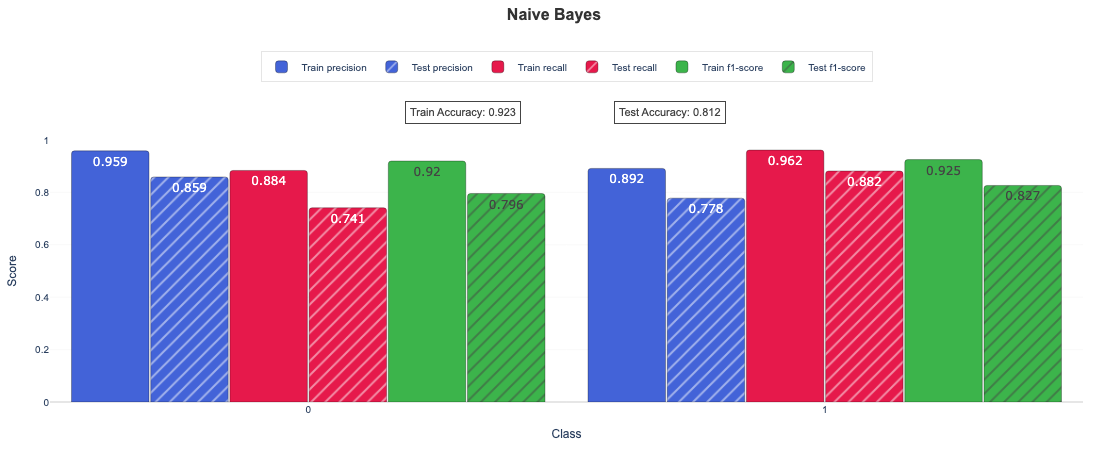

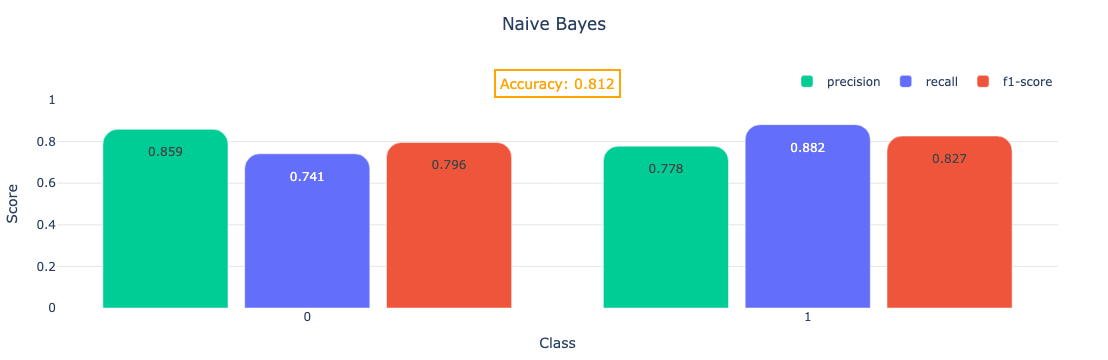

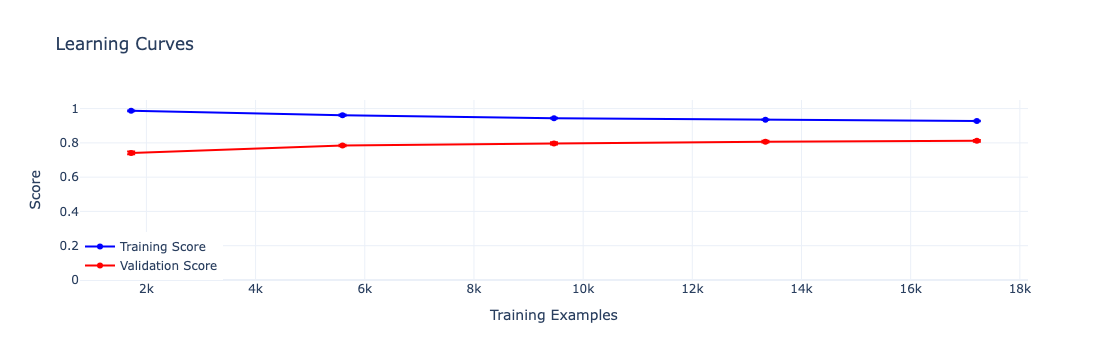

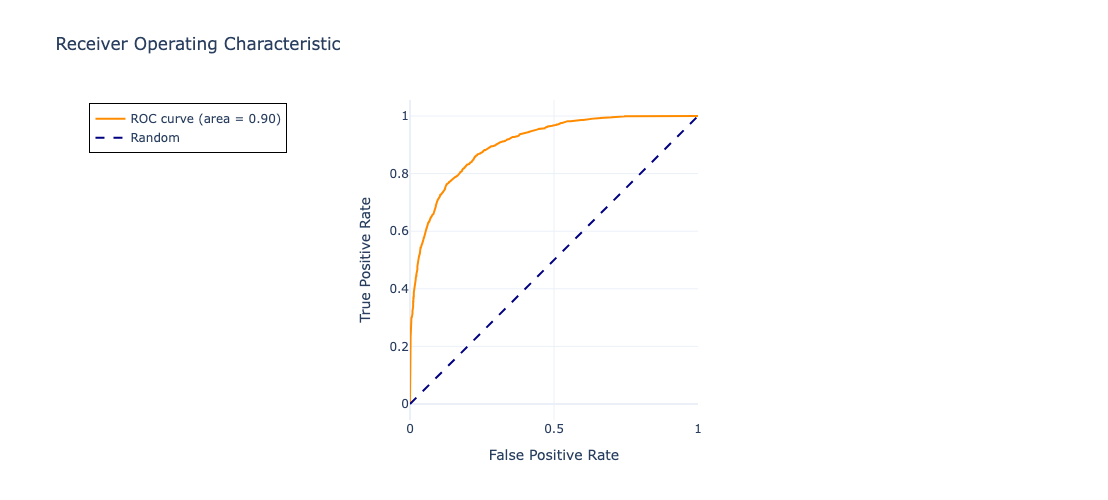

In [4]:
nb_fig_learning, nb_fig_roc, nb_train_report, nb_test_report = train_and_evaluate(
    train_df, test_df, "nb"
)
# Naive Bayes
plot_classification_report("Naive Bayes", nb_train_report, nb_test_report)
plot_classification_test_report("Naive Bayes", nb_test_report)

nb_fig_learning.show()
nb_fig_roc.show()

Cross-validation scores (5-fold): [0.78294213 0.78178015 0.78015338 0.77806182 0.78666047]
Mean CV accuracy: 0.7819
CV Standard deviation: 0.0029


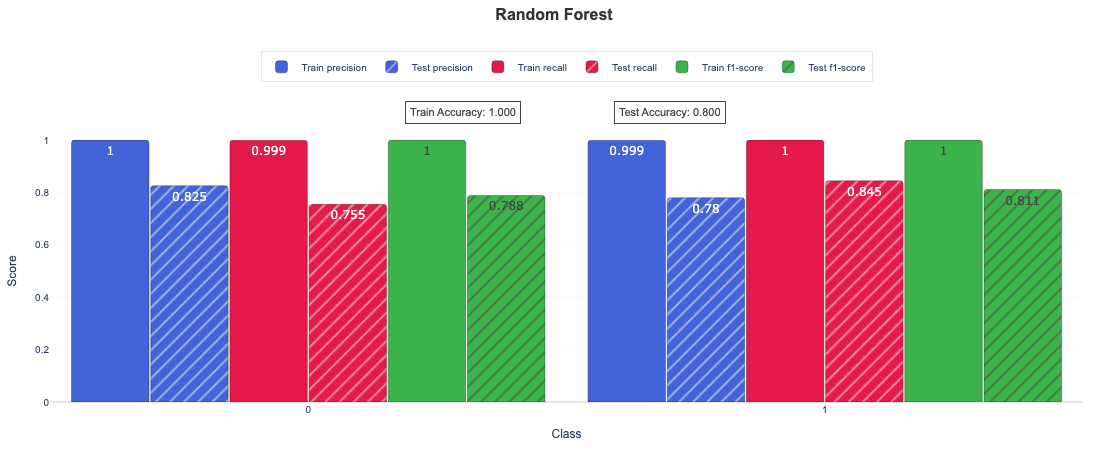

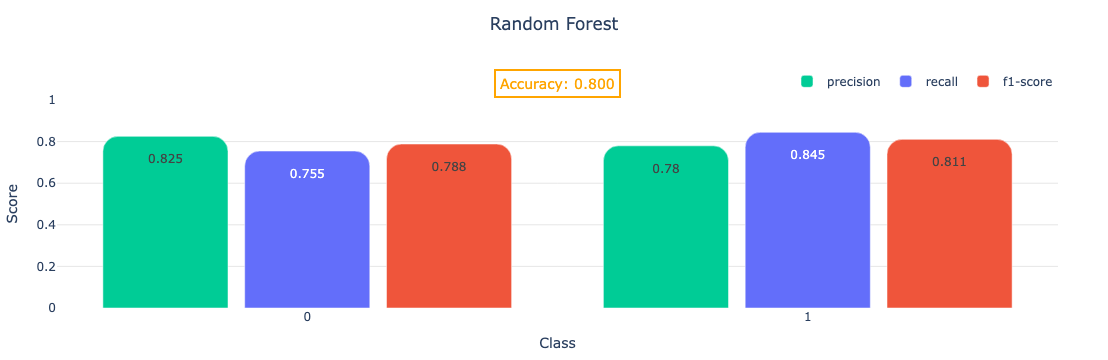

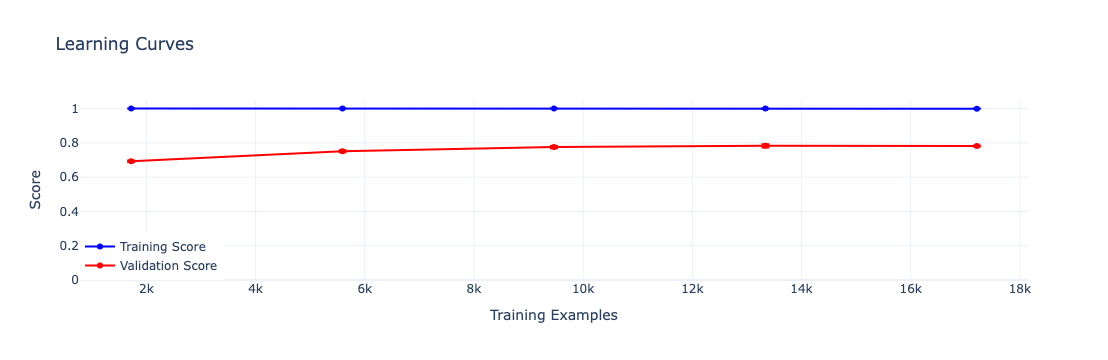

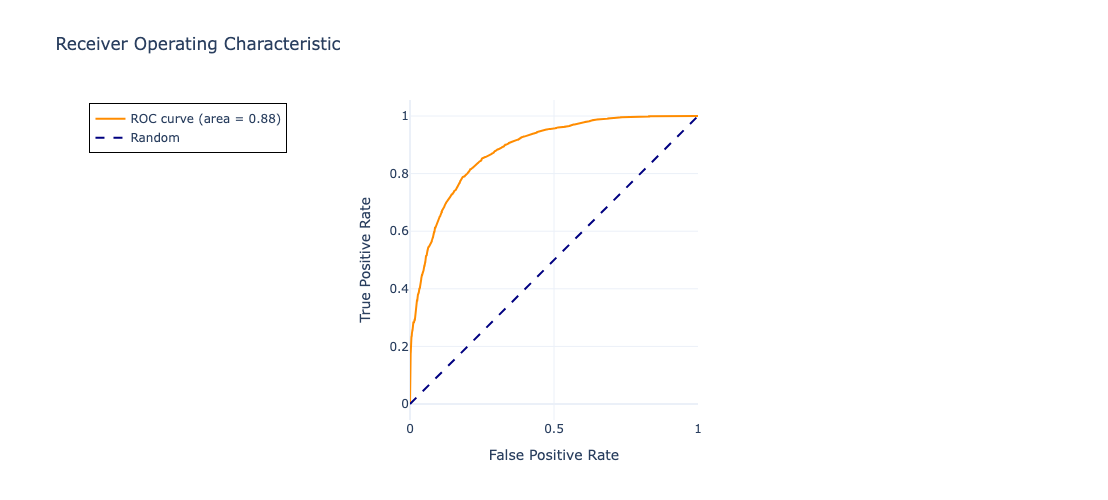

In [5]:
rf_fig_learning, rf_fig_roc, rf_train_report, rf_test_report = train_and_evaluate(
    train_df, test_df, "rf"
)  # Random Forest
plot_classification_report("Random Forest", rf_train_report, rf_test_report)
plot_classification_test_report("Random Forest", rf_test_report)

rf_fig_learning.show()
rf_fig_roc.show()

Cross-validation scores (5-fold): [0.8198931  0.81268882 0.8138508  0.802231   0.82314664]
Mean CV accuracy: 0.8144
CV Standard deviation: 0.0072


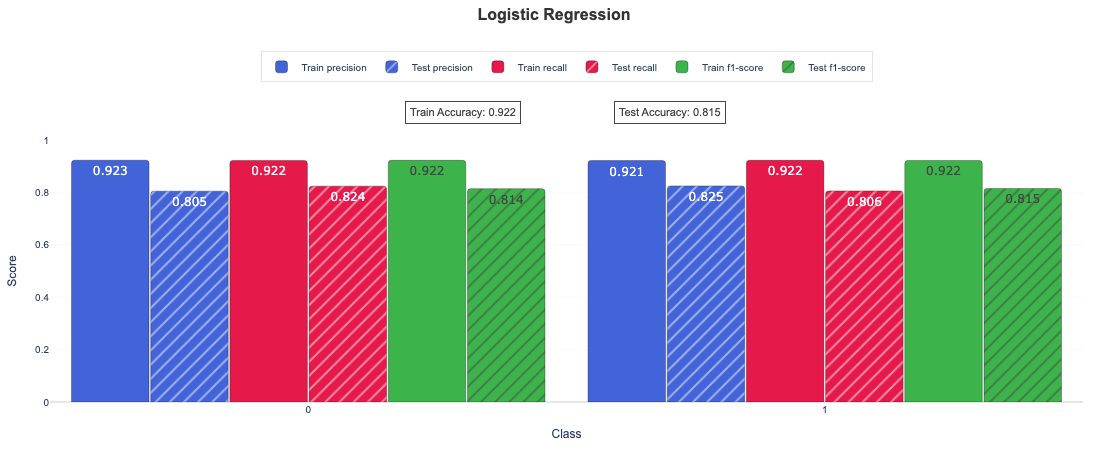

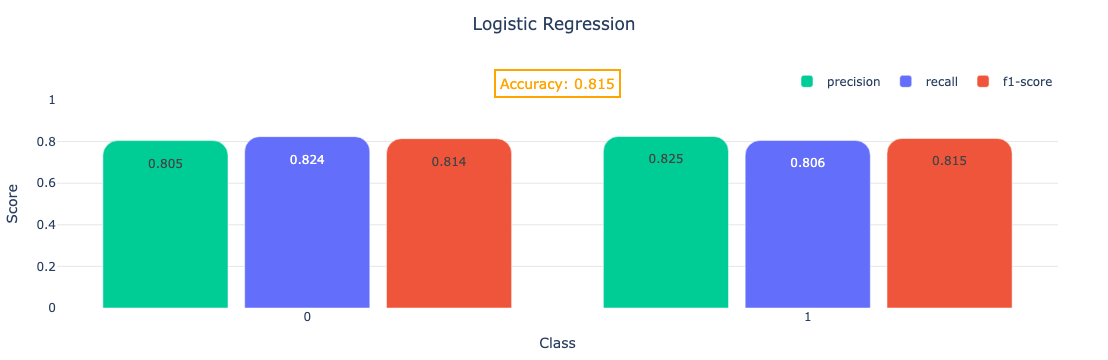

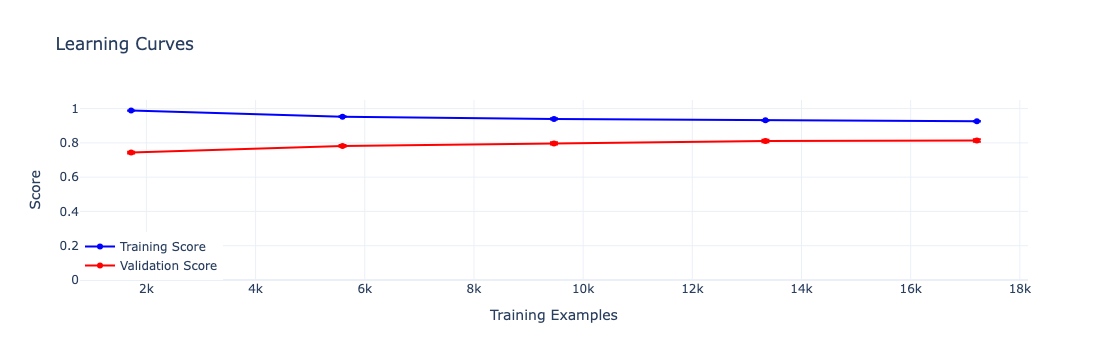

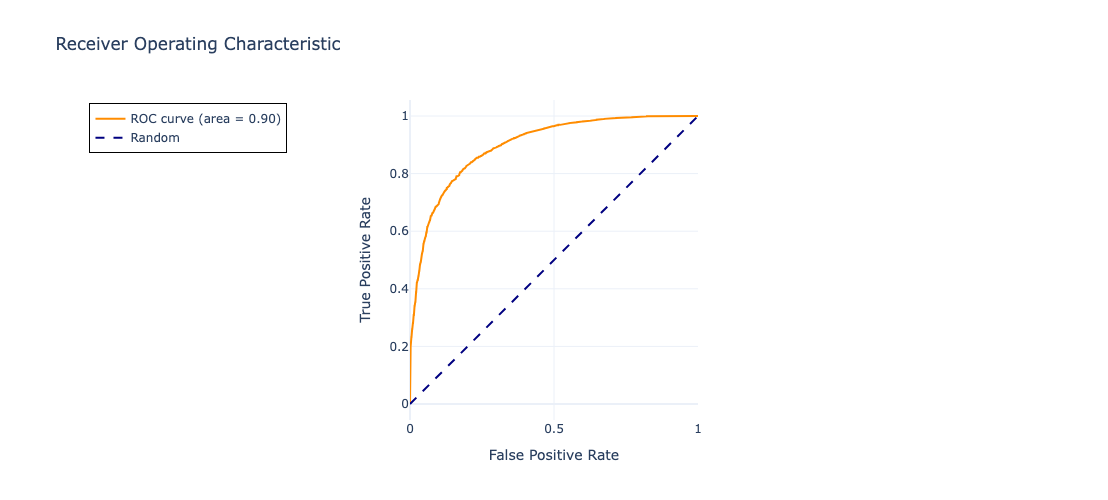

In [6]:
lr_fig_learning, lr_fig_roc, lr_train_report, lr_test_report = train_and_evaluate(
    train_df, test_df, "lr"
)  # Logistic Regression
plot_classification_report("Logistic Regression", lr_train_report, lr_test_report)
plot_classification_test_report("Logistic Regression", lr_test_report)

lr_fig_learning.show()
lr_fig_roc.show()

Cross-validation scores (5-fold): [0.8312805  0.825703   0.82523821 0.81756914 0.82779456]
Mean CV accuracy: 0.8255
CV Standard deviation: 0.0045


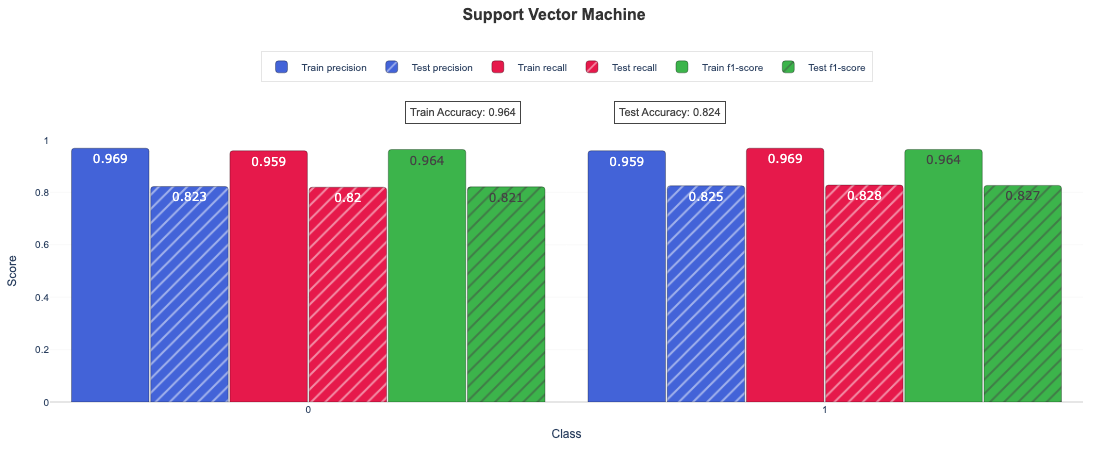

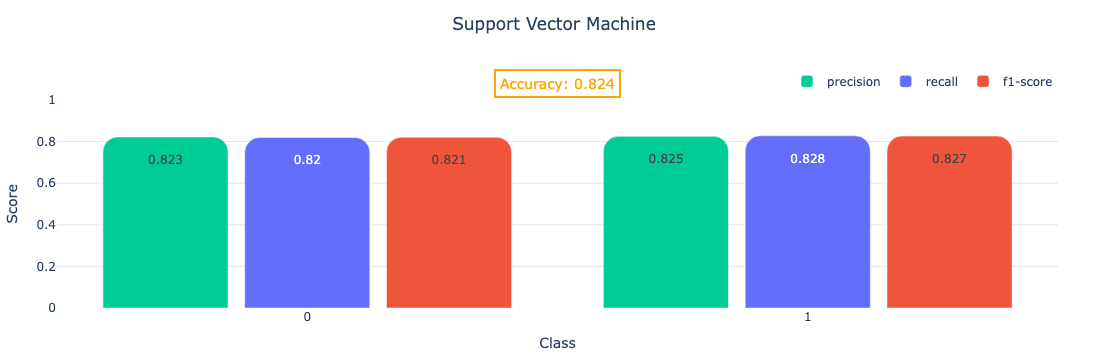

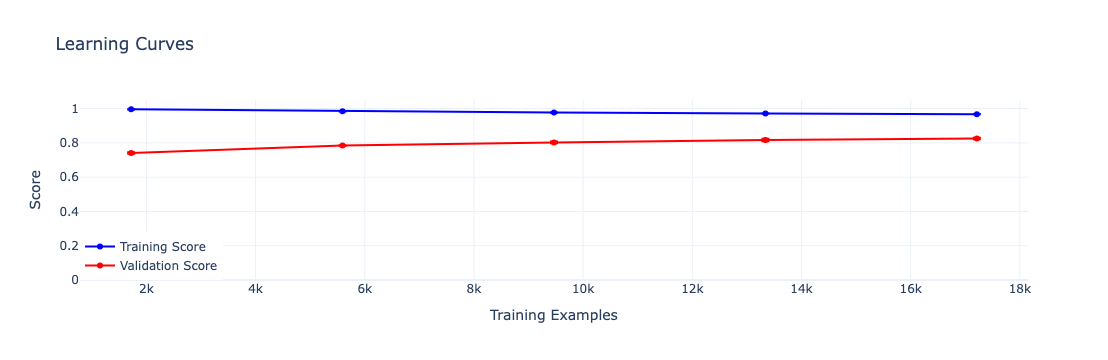

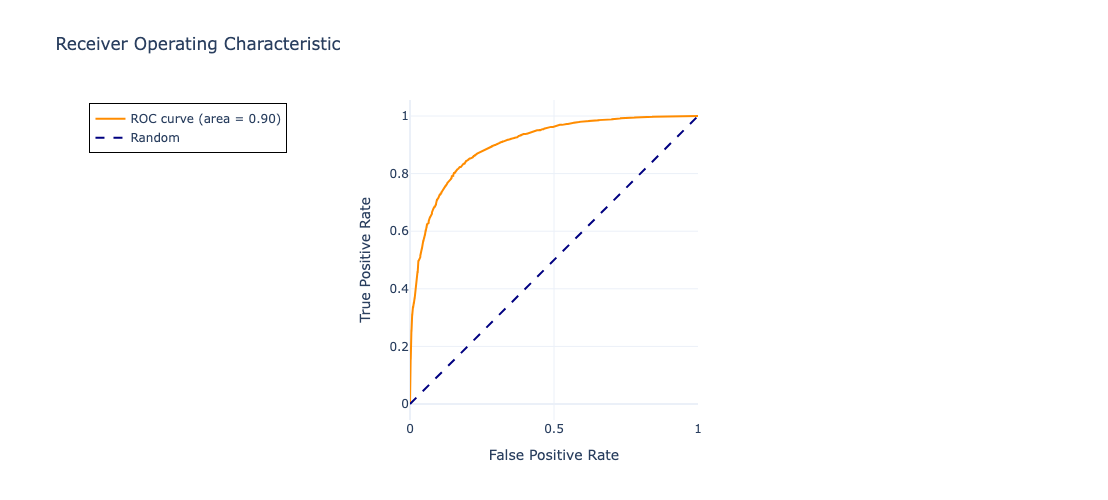

In [7]:
svm_fig_learning, svm_fig_roc, svm_train_report, svm_test_report = train_and_evaluate(
    train_df, test_df, "svm"
)  # Support Vector Machine
plot_classification_report("Support Vector Machine", svm_train_report, svm_test_report)
plot_classification_test_report("Support Vector Machine", svm_test_report)

svm_fig_learning.show()
svm_fig_roc.show()

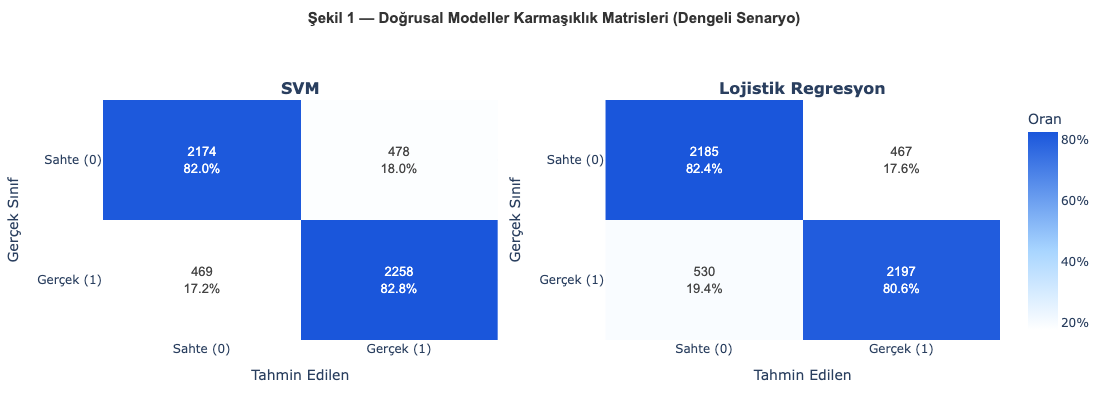

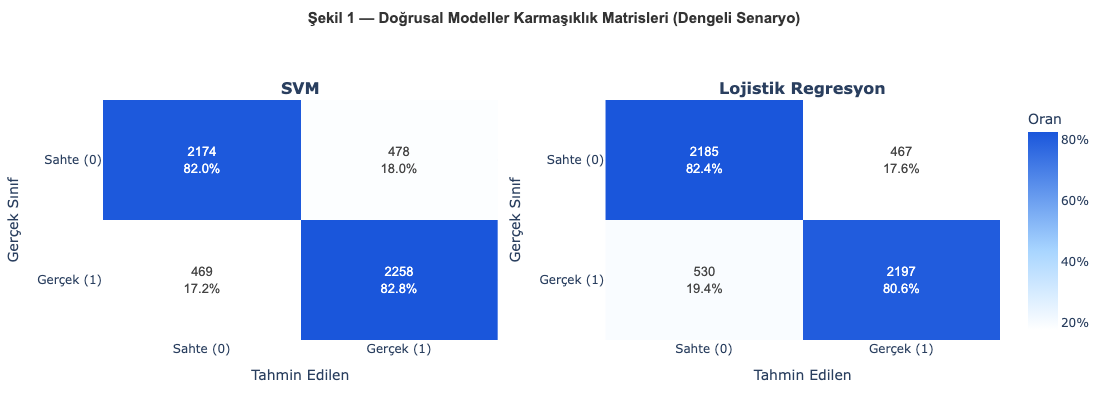

In [8]:

# Şekil 1 — SVM ve LR Karmaşıklık Matrisleri (Dengeli Senaryo)
from graphic import plot_dual_confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

svm_pipe = Pipeline([("tfidf", TfidfVectorizer()), ("clf", SVC(kernel="linear", probability=True, random_state=42))])
svm_pipe.fit(train_df["text"], train_df["is_real"])
svm_preds = svm_pipe.predict(test_df["text"])

lr_pipe = Pipeline([("tfidf", TfidfVectorizer()), ("clf", LogisticRegression(l1_ratio=0, random_state=42))])
lr_pipe.fit(train_df["text"], train_df["is_real"])
lr_preds = lr_pipe.predict(test_df["text"])

plot_dual_confusion_matrix(
    "Şekil 1 — Doğrusal Modeller Karmaşıklık Matrisleri (Dengeli Senaryo)",
    test_df["is_real"], svm_preds, "SVM",
    test_df["is_real"], lr_preds, "Lojistik Regresyon",
)
